In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import math


In [3]:
df=sns.load_dataset('flights')
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [5]:
df['yearMonth']= pd.to_datetime("01-"+ df['month'].astype(str) + "-" + df['year'].astype(str))
df.set_index('yearMonth', inplace=True)

In [7]:
airP= df[['passengers']].copy(deep=True)
print(airP)

            passengers
yearMonth             
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
...                ...
1960-08-01         606
1960-09-01         508
1960-10-01         461
1960-11-01         390
1960-12-01         432

[144 rows x 1 columns]


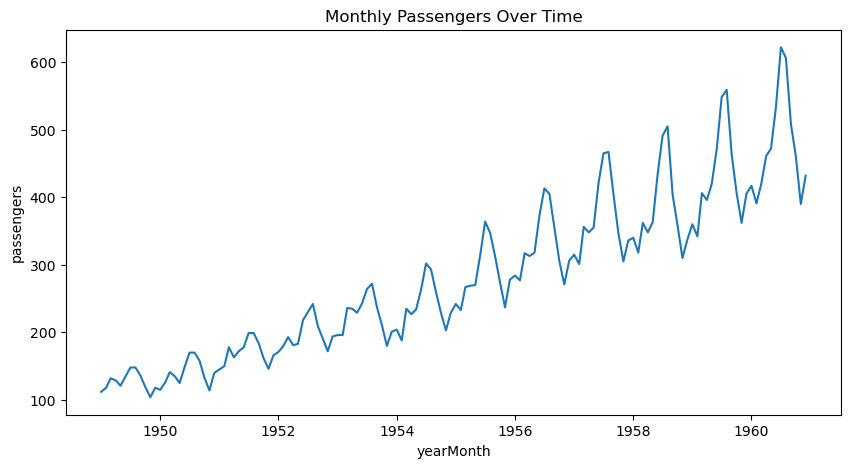

In [8]:
plt.figure(figsize=(10,5))
sns.lineplot(x=airP.index, y=airP['passengers'])
plt.title("Monthly Passengers Over Time")
plt.show()

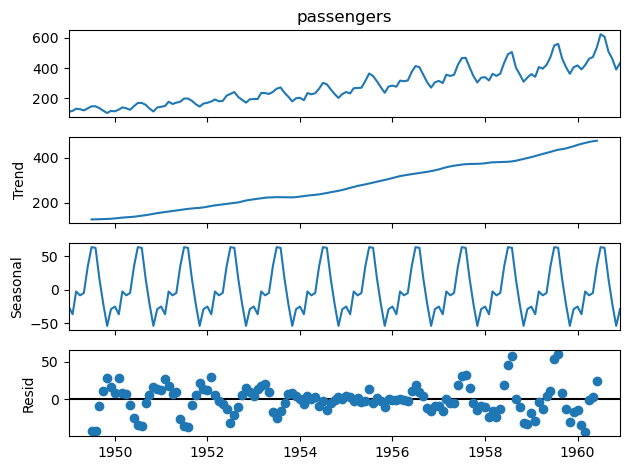

In [9]:
decomposition= seasonal_decompose(airP.passengers, period=12)
decomposition.plot()
plt.show()

In [18]:
def test_stationarity(dataFrame, var, window=12):
    dataFrame['rollMean']= dataFrame[var].rolling(window=window). mean()
    dataFrame['rollStd']= dataFrame[var].rolling(window=window). std()
    adf_result= adfuller(dataFrame[var])
    p_value= adf_result[1]

    print(f"ADF p-value: {p_value:.4f}")
    if p_value <0.5:
        print("The time series is stationary (reject HO). ")
    else:
        print("The time series is not stationary( fail to reject HO).")
    plt.figure(figsize=(10,5))
    sns.lineplot(x=dataFrame.index, y=dataFrame[var], label='Original')
    sns.lineplot(x=dataFrame.index, y=dataFrame['rollStd'], label='rolling Std')
    plt.title("Rolling Statistics")
    plt.legend()
    plt.show()


ADF p-value: 0.9919
The time series is not stationary( fail to reject HO).


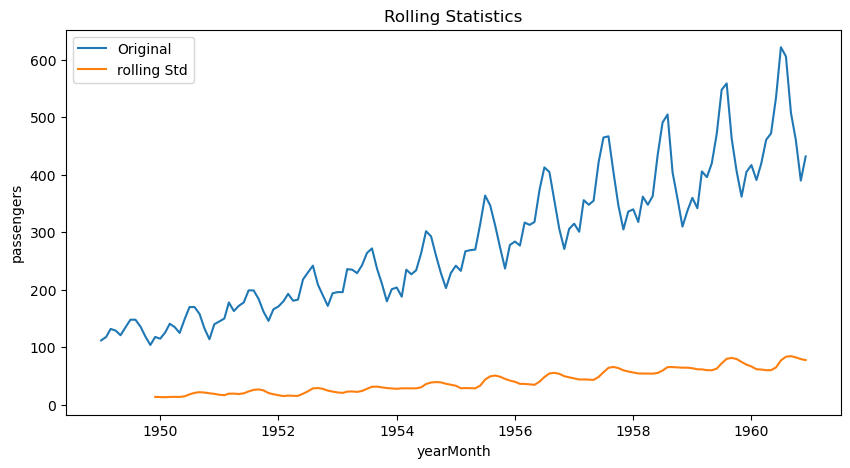

            passengers    rollMean    rollStd  shift  shiftDiff
yearMonth                                                      
1949-01-01         112         NaN        NaN    NaN        NaN
1949-02-01         118         NaN        NaN  112.0        6.0
1949-03-01         132         NaN        NaN  118.0       14.0
1949-04-01         129         NaN        NaN  132.0       -3.0
1949-05-01         121         NaN        NaN  129.0       -8.0
1949-06-01         135         NaN        NaN  121.0       14.0
1949-07-01         148         NaN        NaN  135.0       13.0
1949-08-01         148         NaN        NaN  148.0        0.0
1949-09-01         136         NaN        NaN  148.0      -12.0
1949-10-01         119         NaN        NaN  136.0      -17.0
1949-11-01         104         NaN        NaN  119.0      -15.0
1949-12-01         118  126.666667  13.720147  104.0       14.0
1950-01-01         115  126.916667  13.453342  118.0       -3.0
1950-02-01         126  127.583333  13.1

C:\Users\PGCP-AI\AppData\Local\Temp\ipykernel_7616\1666179841.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollMean']= dataFrame[var].rolling(window=window). mean()
C:\Users\PGCP-AI\AppData\Local\Temp\ipykernel_7616\1666179841.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollStd']= dataFrame[var].rolling(window=window). std()


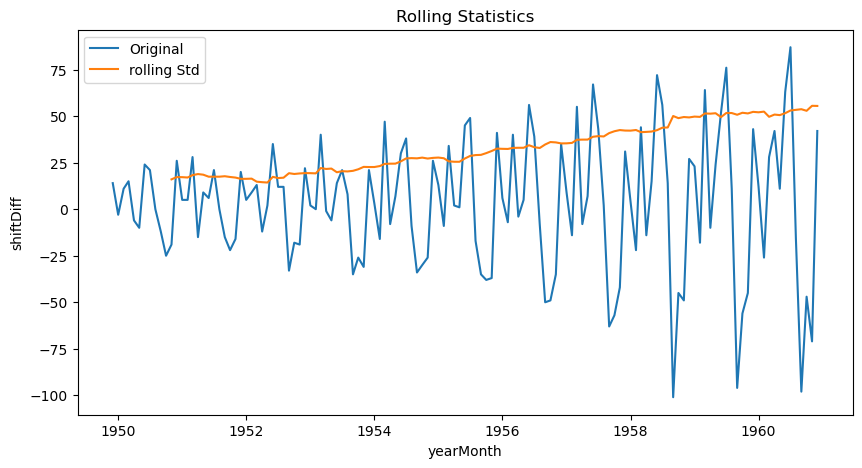

            passengers    rollMean    rollStd  shift  shiftDiff
yearMonth                                                      
1949-01-01         112         NaN        NaN    NaN        NaN
1949-02-01         118         NaN        NaN    NaN        NaN
1949-03-01         132         NaN        NaN  112.0       20.0
1949-04-01         129         NaN        NaN  118.0       11.0
1949-05-01         121         NaN        NaN  132.0      -11.0
1949-06-01         135         NaN        NaN  129.0        6.0
1949-07-01         148         NaN        NaN  121.0       27.0
1949-08-01         148         NaN        NaN  135.0       13.0
1949-09-01         136         NaN        NaN  148.0      -12.0
1949-10-01         119         NaN        NaN  148.0      -29.0
1949-11-01         104         NaN        NaN  136.0      -32.0
1949-12-01         118  126.666667  13.720147  119.0       -1.0
1950-01-01         115  126.916667  13.453342  104.0       11.0
1950-02-01         126  127.583333  13.1

C:\Users\PGCP-AI\AppData\Local\Temp\ipykernel_7616\1666179841.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollMean']= dataFrame[var].rolling(window=window). mean()
C:\Users\PGCP-AI\AppData\Local\Temp\ipykernel_7616\1666179841.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollStd']= dataFrame[var].rolling(window=window). std()


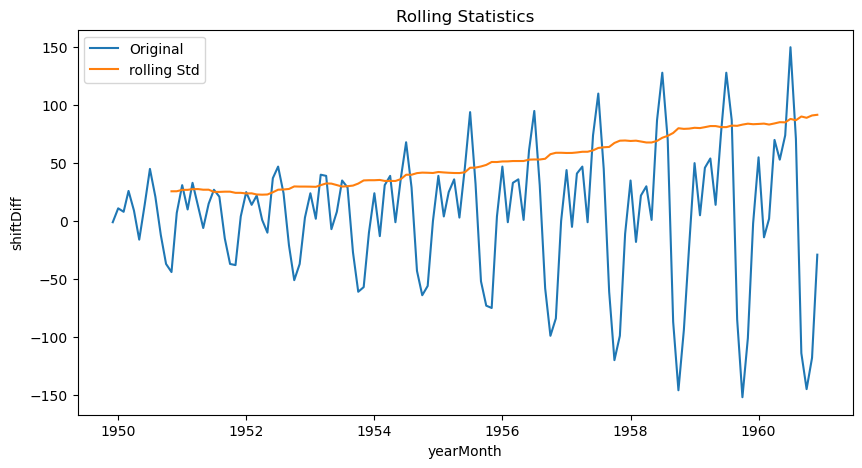

In [19]:
test_stationarity(airP, 'passengers')
airP['shift']= airP.passengers.shift(1)
airP['shiftDiff']= airP['passengers']- airP['shift']
print(airP.head(20))
test_stationarity(airP.dropna(), 'shiftDiff')

airP['shift']= airP.passengers.shift(2)
airP['shiftDiff']= airP['passengers']- airP['shift']
print(airP.head(20))
test_stationarity(airP.dropna(), 'shiftDiff')

In [20]:
airP['secondDiff']= airP['passengers']. diff(2)
airP['Diff12']= airP['passengers']. diff(12)


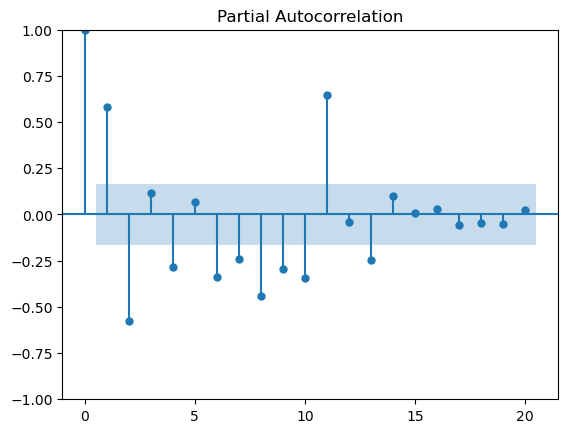

In [21]:
plot_pacf(airP['secondDiff'].dropna(), lags=20)
plt.show()

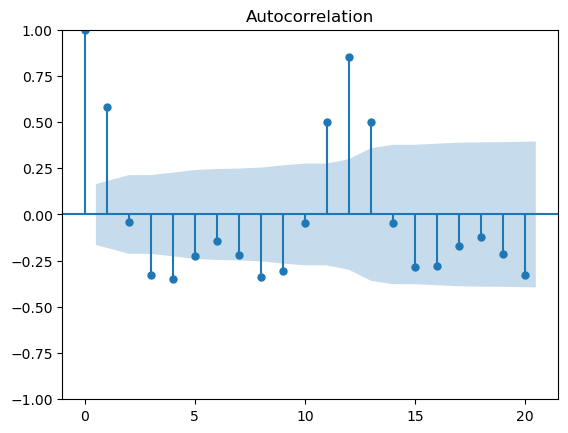

In [23]:
plot_acf(airP['secondDiff'].dropna(), lags=20)
plt.show()

In [22]:
train_size= int(len(airP)*0.7)
train= airP.iloc[:train_size]
test= airP.iloc[train_size:]

In [24]:
model_arima= ARIMA(train['passengers'], order=(1,2,1))
model_arima_fit= model_arima.fit()
arima_pred= model_arima_fit.predict(start=len(train), end=len(airP)-1)

airP['arimaPred']= np.nan
airP.iloc[train_size:, airP.columns.get_loc('arimaPred')]= arima_pred.values
print(airP.tail())

            passengers    rollMean    rollStd  shift  shiftDiff  secondDiff  \
yearMonth                                                                     
1960-08-01         606  463.333333  83.630500  535.0       71.0        71.0   
1960-09-01         508  467.083333  84.617276  622.0     -114.0      -114.0   
1960-10-01         461  471.583333  82.541954  606.0     -145.0      -145.0   
1960-11-01         390  473.916667  79.502382  508.0     -118.0      -118.0   
1960-12-01         432  476.166667  77.737125  461.0      -29.0       -29.0   

            Diff12   arimaPred  
yearMonth                       
1960-08-01    47.0  439.708767  
1960-09-01    45.0  442.074513  
1960-10-01    54.0  444.440259  
1960-11-01    28.0  446.806004  
1960-12-01    27.0  449.171750  


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


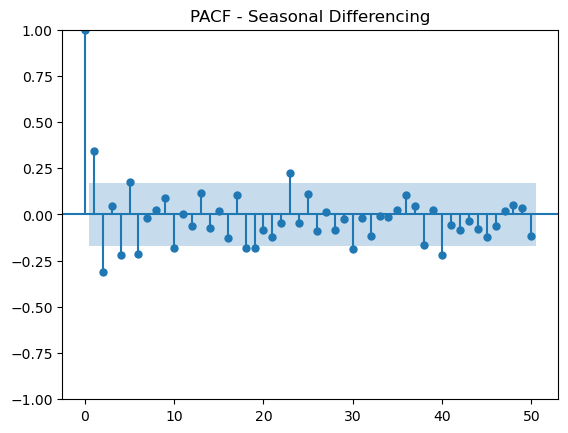

In [25]:
airP['diff_combined']= airP['passengers']. diff(2).diff(12)
plot_pacf(airP['diff_combined'].dropna(), lags=50)
plt.title("PACF - Seasonal Differencing")
plt.show()

In [26]:
model_sarimax= SARIMAX(train['passengers'], order=(1,2,1), seasonal_order=(1,2,1,12))
model_sarimax_fit= model_sarimax.fit()
sarimax_pred= model_sarimax_fit.predict(start=len(train), end=len(airP)-1)


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [27]:
airP['sarimaxPred']= np.nan
airP.iloc[train_size:, airP.columns.get_loc('sarimaxPred')]= sarimax_pred.values
print(airP.tail(20))

            passengers    rollMean    rollStd  shift  shiftDiff  secondDiff  \
yearMonth                                                                     
1959-05-01         420  397.083333  60.008270  406.0       14.0        14.0   
1959-06-01         472  400.166667  63.009138  396.0       76.0        76.0   
1959-07-01         548  404.916667  71.987951  420.0      128.0       128.0   
1959-08-01         559  409.416667  80.049369  472.0       87.0        87.0   
1959-09-01         463  414.333333  81.485451  548.0      -85.0       -85.0   
1959-10-01         407  418.333333  79.680422  559.0     -152.0      -152.0   
1959-11-01         362  422.666667  74.498729  463.0     -101.0      -101.0   
1959-12-01         405  428.333333  69.830097  407.0       -2.0        -2.0   
1960-01-01         417  433.083333  66.624399  362.0       55.0        55.0   
1960-02-01         391  437.166667  61.866180  405.0      -14.0       -14.0   
1960-03-01         419  438.250000  61.382741  417.0

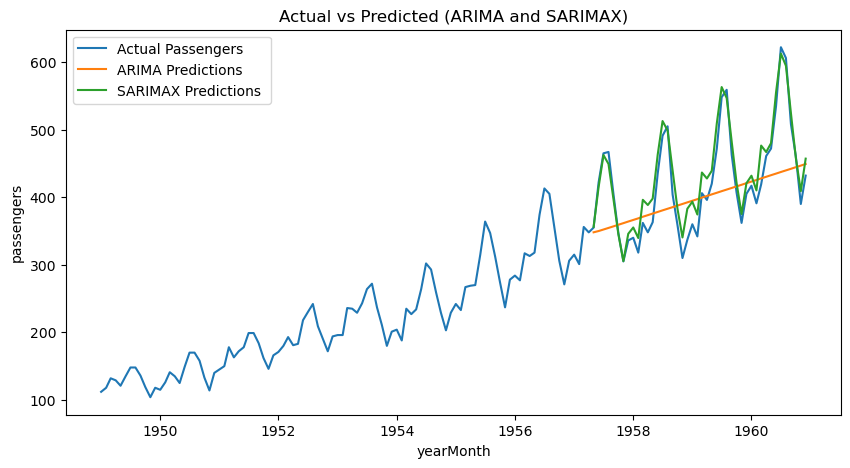

In [30]:
plt.figure(figsize=(10,5))
sns.lineplot(x=airP.index, y=airP['passengers'], label='Actual Passengers ')
sns.lineplot(x=airP.index, y=airP['arimaPred'], label='ARIMA Predictions ')
sns.lineplot(x=airP.index, y=airP['sarimaxPred'], label='SARIMAX Predictions ')
plt.title('Actual vs Predicted (ARIMA and SARIMAX)')
plt.legend()
plt.show()

In [31]:
future_dates= pd.DataFrame(pd.date_range(start='1961-01-01', end='1962-12-01', freq='MS'), columns=['Dates'])
future_dates.set_index('Dates', inplace=True)

In [32]:
model_sarimax_fit.predict(start=future_dates.index[0], end=future_dates.index[-1])
print(future_forecast)

NameError: name 'future_forecast' is not defined

NameError: name 'future_forecast' is not defined

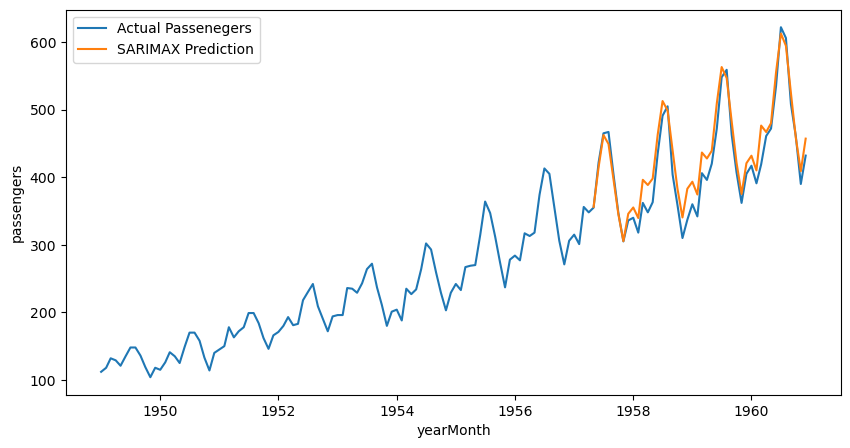

In [33]:
plt.figure(figsize=(10,5))
sns.lineplot(x=airP.index, y=airP['passengers'], label='Actual Passenegers')
sns.lineplot(x=airP.index, y=airP['sarimaxPred'], label='SARIMAX Prediction')
future_forecast.plot(color='black', label='Future Forecast')
plt.title('SARIMAX model with Future Forecast')
plt.legend()
plt.show()

actual= test['passengers']

In [41]:
actual=['passengers']

In [42]:
arima_mae= mean_absolute_error(actual, arima_pred)
arima_mse= mean_squared_error(actual, arima_pred)
arima_rmse= math.sqrt(arima_mse)
arima_r2= r2_score(actual, arima_pred)
print(f"ARIMA-> MAE: {arima_mae:.2f}, RMSE: {arima_rmse:.2f}, R2: {arima_r2:.2f}")


ValueError: Found input variables with inconsistent numbers of samples: [1, 44]

In [39]:
sarimax_mae= mean_absolute_error(actual, sarimax_pred)
sarimax_mse= mean_squared_error(actual, sarimax_pred)
sarimax_rmse= math.sqrt( sarimax_mse)
sarimax_r2= r2_score(actual, sarimax_pred)
print(f"SARIMAX -> MAE: {sarimax_mae:.2f}, RMSE:{sarimax_rmse:.2f}, R2: {sarimax_r2:.2f}")

ValueError: Found input variables with inconsistent numbers of samples: [1, 44]